# CRE Assignment 4 - Group 2

---

## Table of Contents

**1. Background**&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; \
&emsp;1.1 Residence Time Distribution \
&emsp;1.2 Backmixing Models for PFR \
&emsp;&emsp;1.2.1 Dispersion Model \
&emsp;&emsp;1.2.2 Danckwerts Boundary Conditions 

**2. Mathematical Framework** \
&emsp;2.1 Governing Equations\
&emsp;2.2 Boundary Conditions (Danckwerts)\
&emsp;2.3 CSTR Cascade Model

**3. Implementation**\
&emsp;3.1 Parameters and Setup\
&emsp;3.2 BVP Solver — Dispersion Model\
&emsp;3.3 IVP Solver — PFR Limiting Case\
&emsp;3.4 CSTR Cascade

**4. Results and Discussion**\
&emsp;4.1 Validation — BVP vs. IVP\
&emsp;4.2 Influence of Backmixing (Bo-Number Variation)\
&emsp;&emsp;Theoretical and practical boundary cases\
&emsp;4.3 CSTR Cascade vs. Dispersion Model\

**5. Conclusions**

**6. AI Use and Reflection**

---

In [16]:
# ============================================================
# IMPORT SECTION
# ============================================================

import numpy as np                          # numerical arrays and math
import scipy.integrate as integ             # initial value problem solver (solve_ivp)
from scipy.integrate import solve_bvp       # boundary value problem solver
import matplotlib.pyplot as plt             # plotting
from matplotlib.lines import Line2D         # custom legend handles
from matplotlib.patches import Patch        # custom legend handles (filled)

In [17]:
# ============================================================
# GLOBAL PARAMETERS
# ============================================================

# --- Reactor geometry ---
L    = 10.0             # reactor length, m
d_R  = 0.032            # reactor tube inner diameter, m
d_in = 0.150            # upstream pipe diameter (feed section), m

A_R  = np.pi / 4 * d_R**2   # reactor cross-sectional area, m^2
A_in = np.pi / 4 * d_in**2  # feed pipe cross-sectional area, m^2

# --- Flow conditions ---
V_dot = 1e-3            # volumetric flow rate, m^3/s  (1 L/s)

u_in = V_dot / A_in     # mean velocity in feed pipe, m/s
u    = V_dot / A_R      # mean velocity in reactor tube, m/s

tau  = L / u            # mean residence time in reactor, s

# --- Feed conditions ---
c_A_in = 100.0          # inlet concentration of component A, mol/m^3
c_B_in = 0.0            # inlet concentration of component B, mol/m^3

# --- Spatial grid ---
N_points = 200          # number of collocation points for BVP solver
z = np.linspace(0, L, N_points)   # spatial coordinate along reactor axis, m

In [18]:
# ============================================================
# 3.2  BVP SOLVER — DISPERSION MODEL (base case)
# ============================================================
from functools import partial

# --- Study parameters (base case) ---
Da = 2.0          # Damkoehler number  Da = k*tau, -      (fixed for now)
Bo = 10.0         # Bodenstein number  Bo = u*L/D_ax, -   (representative base value)

# --- Derived physical parameters (from global geometry / flow) ---
k    = Da / tau         # reaction rate constant, 1/s          (Da = k*tau)
D_ax = u * L / Bo       # axial dispersion coefficient, m^2/s   (Bo = u*L/D_ax)

# --- Model definition (Guettel Gl. 15.2a, p. 209) -----------
# Steady-state dispersion model, 1st-order reaction A -> B:
#   D_ax * c_A'' - u * c_A' - k * c_A = 0
# as a 1st-order system with y[0] = c_A, y[1] = dc_A/dz:
#   y[0]' = y[1]
#   y[1]' = (u/D_ax)*y[1] + (k/D_ax)*y[0]
def dispersion_rhs(z, y, k, D, u):
    "RHS of the dispersion-model ODE system."
    dc_A  = y[1]
    d2c_A = (u / D) * y[1] + (k / D) * y[0]
    return np.vstack((dc_A, d2c_A))

# --- Danckwerts boundary conditions (Guettel Gl. 15.2b/c, p. 209) ---
# inlet  (z=0):  c_A,e = c_A(0) - (D_ax/u) * dc_A/dz|_0   (backmixing -> inlet jump)
# outlet (z=L):  dc_A/dz|_L = 0                           (zero-gradient)
def dispersion_bc(ya, yb, D, u, c_in):
    "Residuals of the two Danckwerts boundary conditions."
    bc_inlet  = ya[0] - (D / u) * ya[1] - c_in
    bc_outlet = yb[1]
    return np.array([bc_inlet, bc_outlet])

# --- Bind fixed parameters (solve_bvp takes no 'args', unlike solve_ivp) ---
fun = partial(dispersion_rhs, k=k, D=D_ax, u=u)
bc  = partial(dispersion_bc,  D=D_ax, u=u, c_in=c_A_in)

# --- Initial mesh and guess ---
N_nodes = 200
z_mesh  = np.linspace(0, L, N_nodes)
y_guess = np.zeros((2, N_nodes))
y_guess[0] =  c_A_in * np.exp(-k / u * z_mesh)        # PFR-like decay as starting guess
y_guess[1] = -k / u * c_A_in * np.exp(-k / u * z_mesh)

# --- Solve ---
sol = solve_bvp(fun, bc, z_mesh, y_guess, tol=1e-8, max_nodes=100000)

# --- Diagnostics ---
c_A0 = sol.sol(0.0)[0]
c_AL = sol.sol(L)[0]
X    = 1 - c_AL / c_A_in
print(f"solver success : {sol.success}  (iterations: {sol.niter}, nodes: {sol.x.size})")
print(f"Da = {k*tau:.3f} | Bo = {u*L/D_ax:.3f}")
print(f"c_A(0) = {c_A0:.2f} mol/m3   (feed c_A,e = {c_A_in:.0f} mol/m3)")
print(f"c_A(L) = {c_AL:.2f} mol/m3")
print(f"conversion X = {X:.4f}")

solver success : True  (iterations: 4, nodes: 460)
Da = 2.000 | Bo = 10.000
c_A(0) = 85.41 mol/m3   (feed c_A,e = 100 mol/m3)
c_A(L) = 17.73 mol/m3
conversion X = 0.8227


# Erklären, dass ivp.solver Einsatz im Idealen PFTR Case drin steckt, und das auch analytisch gemacht werden kann. Geh dabei auf die Herkunft der Formel in Güttel ein.

In [19]:
# ============================================================
# ANALYTICAL REFERENCE SOLUTIONS (1st-order reaction)
# ============================================================
# Used both for the base-case comparison lines and for validation.

def X_pfr(Da):
    "Conversion of an ideal plug-flow reactor (limit Bo -> inf)."
    return 1 - np.exp(-Da)

def X_cstr(Da):
    "Conversion of a single ideal CSTR / fully backmixed reactor (limit Bo -> 0)."
    return Da / (1 + Da)

def X_dispersion(Bo, Da):
    "Outlet conversion of the closed-closed dispersion model (Guettel Gl. 15.6, p. 209)."
    b = np.sqrt(1 + 4 * Da / Bo)
    denom = (1 + b)**2 * np.exp(-Bo * (1 - b) / 2) - (1 - b)**2 * np.exp(-Bo * (1 + b) / 2)
    return 1 - 4 * b / denom

def cA_pfr_profile(z, c_in, k, u):
    "Concentration profile of an ideal PFR: c_A(z) = c_A,e * exp(-k z / u)."
    return c_in * np.exp(-k * z / u)

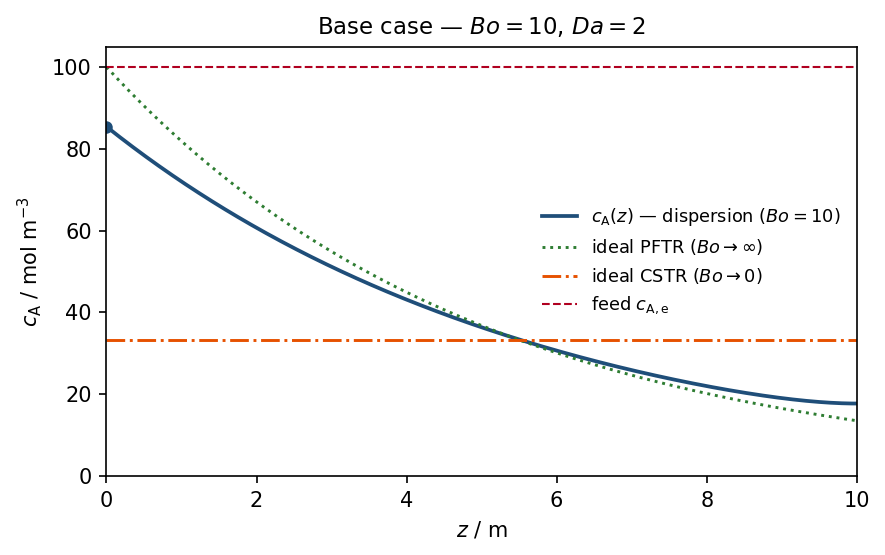

In [21]:
# ============================================================
# 3.2  PLOT — base-case profile with ideal-reactor references
# ============================================================
# --- plot variables (top of cell) ---
fig_w, fig_h, fig_dpi = 6, 3.8, 150
col_disp, col_pfr, col_cstr, col_feed = "#1f4e79", "#2e7d32", "#e65100", "#b00020"
lw_disp, n_eval = 1.8, 400

# --- data ---
z_eval  = np.linspace(0, L, n_eval)
cA_eval = sol.sol(z_eval)[0]
cA0     = sol.sol(0.0)[0]
cA_cstr = c_A_in * (1 - X_cstr(Da))          # constant level of an ideal CSTR (same tau)

fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=fig_dpi)
ax.plot(z_eval, cA_eval, color=col_disp, lw=lw_disp,
        label=rf"$c_\mathrm{{A}}(z)$ — dispersion ($Bo={Bo:.0f}$)")
ax.plot(z_eval, cA_pfr_profile(z_eval, c_A_in, k, u), color=col_pfr, lw=1.4, ls=":",
        label=r"ideal PFTR ($Bo\to\infty$)")
ax.axhline(cA_cstr, color=col_cstr, lw=1.4, ls="-.",
           label=r"ideal CSTR ($Bo\to 0$)")
ax.axhline(c_A_in, color=col_feed, lw=1.0, ls="--",
           label=r"feed $c_\mathrm{A,e}$")
ax.plot(0, cA0, "o", color=col_disp, ms=5)

ax.set_xlabel(r"$z$ / m")
ax.set_ylabel(r"$c_\mathrm{A}$ / mol m$^{-3}$")
ax.set_xlim(0, L)
ax.set_ylim(0, c_A_in * 1.05)
ax.set_title(rf"Base case — $Bo = {Bo:.0f}$, $Da = {Da:.0f}$", fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc="right")
fig.tight_layout()
plt.show()

In [22]:
# ============================================================
# 4.1  VALIDATION — BVP vs analytical solution over Bo
# ============================================================
def solve_dispersion(Bo, N=400):
    "Solve the dispersion-model BVP for a given Bodenstein number; return the solution object."
    "This is a wrapper around the BVP solver to allow varying Bo while keeping other parameters fixed."
    "This is the function which will be validated numerically against the analytical solution X_dispersion(Bo, Da), and therefor used in the later assignment exclusively"
    D   = u * L / Bo
    fun = partial(dispersion_rhs, k=k, D=D, u=u)
    bc  = partial(dispersion_bc,  D=D, u=u, c_in=c_A_in)
    z   = np.linspace(0, L, N)
    yg  = np.zeros((2, N))
    yg[0] =  c_A_in * np.exp(-k / u * z)
    yg[1] = -k / u * c_A_in * np.exp(-k / u * z)
    return solve_bvp(fun, bc, z, yg, tol=1e-8, max_nodes=200000)

# --- Bo grid spanning CSTR-like to PFR-like behaviour ---
Bo_check = np.logspace(-2, 4, 13)        # 0.01 ... 10000

# --- numerical (BVP) vs analytical (Guettel Gl. 15.6) conversion ---
X_bvp = np.array([1 - solve_dispersion(Bo_i).sol(L)[0] / c_A_in for Bo_i in Bo_check])
X_ana = X_dispersion(Bo_check, Da)

# --- report ---
print(f"{'Bo':>10} | {'X_BVP':>9} | {'X_analytical':>12} | {'abs. diff':>10}")
print("-" * 52)
for Bo_i, xb, xa in zip(Bo_check, X_bvp, X_ana):
    print(f"{Bo_i:>10.2f} | {xb:>9.5f} | {xa:>12.5f} | {abs(xb-xa):>10.1e}")
print("-" * 52)
print(f"max. absolute deviation   : {np.max(np.abs(X_bvp - X_ana)):.2e}")
print(f"ideal CSTR limit (Bo->0)  : X = {X_cstr(Da):.5f}")
print(f"ideal PFTR limit (Bo->inf): X = {X_pfr(Da):.5f}")

        Bo |     X_BVP | X_analytical |  abs. diff
----------------------------------------------------
      0.01 |   0.66740 |      0.66740 |    9.0e-11
      0.03 |   0.66898 |      0.66898 |    0.0e+00
      0.10 |   0.67381 |      0.67381 |    4.4e-16
      0.32 |   0.68762 |      0.68762 |    3.7e-15
      1.00 |   0.72061 |      0.72061 |    2.2e-14
      3.16 |   0.77396 |      0.77396 |    6.6e-14
     10.00 |   0.82267 |      0.82267 |    1.0e-13
     31.62 |   0.84901 |      0.84901 |    1.5e-13
    100.00 |   0.85941 |      0.85941 |    2.0e-13
    316.23 |   0.86297 |      0.86297 |    2.2e-13
   1000.00 |   0.86412 |      0.86412 |    2.3e-13
   3162.28 |   0.86449 |      0.86449 |    2.3e-13
  10000.00 |   0.86461 |      0.86461 |    1.8e-13
----------------------------------------------------
max. absolute deviation   : 8.96e-11
ideal CSTR limit (Bo->0)  : X = 0.66667
ideal PFTR limit (Bo->inf): X = 0.86466


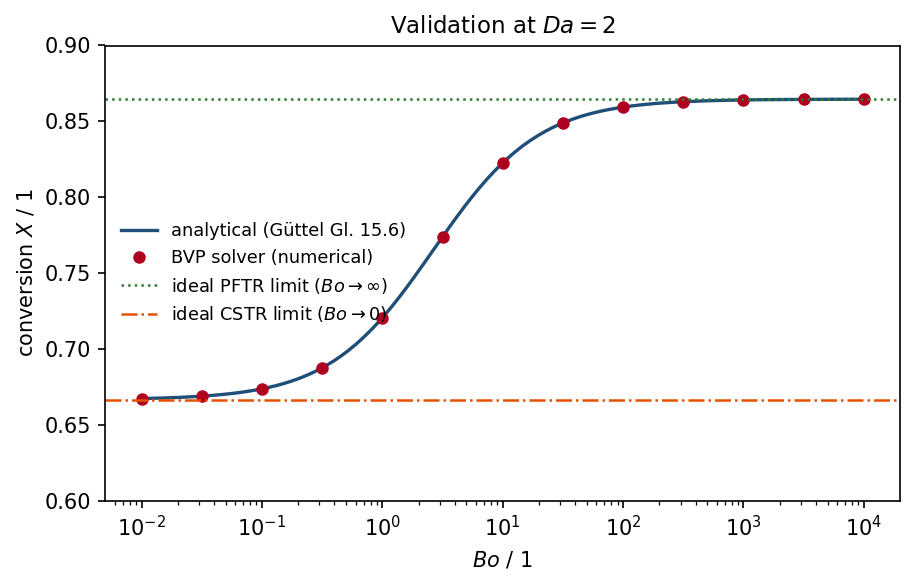

In [23]:
# ============================================================
# 4.1  PLOT — validation of the BVP against analytical limits
# ============================================================
# --- plot variables (top of cell) ---
fig_w, fig_h, fig_dpi = 6.2, 4, 150
col_ana, col_bvp, col_pfr, col_cstr = "#1f4e79", "#b00020", "#2e7d32", "#e65100"
n_line = 200

# --- smooth analytical curve + BVP markers ---
Bo_line = np.logspace(-2, 4, n_line)
X_line  = X_dispersion(Bo_line, Da)

fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=fig_dpi)
ax.plot(Bo_line, X_line, color=col_ana, lw=1.6, label="analytical (Güttel Gl. 15.6)")
ax.plot(Bo_check, X_bvp, "o", color=col_bvp, ms=5, label="BVP solver (numerical)")
ax.axhline(X_pfr(Da),  color=col_pfr,  lw=1.2, ls=":",  label=r"ideal PFTR limit ($Bo\to\infty$)")
ax.axhline(X_cstr(Da), color=col_cstr, lw=1.2, ls="-.", label=r"ideal CSTR limit ($Bo\to 0$)")

ax.set_xscale("log")
ax.set_xlabel(r"$Bo$ / 1")
ax.set_ylabel(r"conversion $X$ / 1")
ax.set_ylim(0.6, 0.9)
ax.set_title(rf"Validation at $Da = {Da:.0f}$", fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc="center left")
fig.tight_layout()
plt.show()

In [24]:
# ============================================================
# 4.2  Bo-SWEEP — concentration profiles (Guettel Abb. 15.2 style)
# ============================================================
# Fixed Da, varying Bo: the profile transitions from CSTR-like (low Bo,
# strong backmixing) to PFR-like (high Bo, weak backmixing).

Bo_sweep = np.array([0.5, 1, 3, 10, 30, 100])

# solve the BVP for each Bo and store the dimensionless profile f_A = c_A / c_A,e
n_prof   = 400
zeta     = np.linspace(0, 1, n_prof)              # dimensionless axial coordinate z/L
profiles = []
print(f"{'Bo':>6} | {'f(0)':>6} | {'f(L)':>6} | {'X':>6}")
print("-" * 33)
for Bo_i in Bo_sweep:
    sol_i = solve_dispersion(Bo_i, N=400)
    f_i   = sol_i.sol(zeta * L)[0] / c_A_in        # f_A(zeta) = c_A(z) / c_A,e
    profiles.append(f_i)
    print(f"{Bo_i:>6.1f} | {f_i[0]:>6.3f} | {f_i[-1]:>6.3f} | {1 - f_i[-1]:>6.3f}")

    Bo |   f(0) |   f(L) |      X
---------------------------------
   0.5 |  0.442 |  0.302 |  0.698
   1.0 |  0.519 |  0.279 |  0.721
   3.0 |  0.687 |  0.229 |  0.771
  10.0 |  0.854 |  0.177 |  0.823
  30.0 |  0.941 |  0.152 |  0.848
 100.0 |  0.981 |  0.141 |  0.859


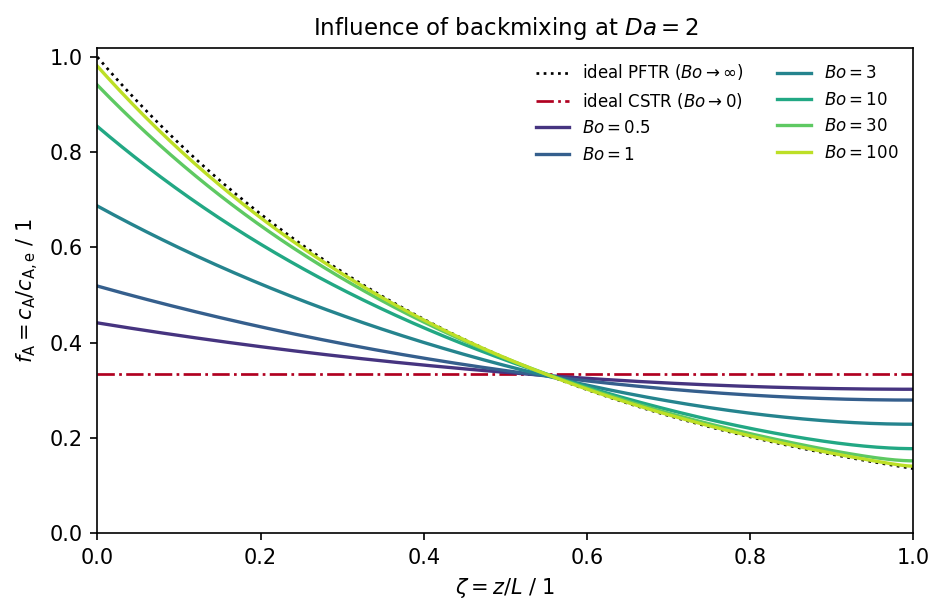

In [25]:
# ============================================================
# 4.2  PLOT — Bo-sweep concentration profiles
# ============================================================
# --- plot variables (top of cell) ---
fig_w, fig_h, fig_dpi = 6.4, 4.2, 150
cmap     = plt.cm.viridis
col_pfr  = "#000000"
col_cstr = "#b00020"
lw_prof  = 1.6
n_cases  = len(Bo_sweep)

# colour-grade the BVP profiles by their position in the sweep (low -> high Bo)
colors = cmap(np.linspace(0.15, 0.9, n_cases))

fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=fig_dpi)

# analytical bounding cases (theoretical limits)
ax.plot(zeta, np.exp(-Da * zeta), color=col_pfr, lw=1.3, ls=":",
        label=r"ideal PFTR ($Bo\to\infty$)")
ax.axhline(1 / (1 + Da), color=col_cstr, lw=1.3, ls="-.",
           label=r"ideal CSTR ($Bo\to 0$)")

# BVP profiles for increasing Bo
for f_i, Bo_i, c in zip(profiles, Bo_sweep, colors):
    ax.plot(zeta, f_i, color=c, lw=lw_prof, label=rf"$Bo = {Bo_i:g}$")

ax.set_xlabel(r"$\zeta = z/L$ / 1")
ax.set_ylabel(r"$f_\mathrm{A} = c_\mathrm{A}/c_\mathrm{A,e}$ / 1")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_title(rf"Influence of backmixing at $Da = {Da:.0f}$", fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="upper right", ncol=2)
fig.tight_layout()
plt.show()

## 6. AI Use and Reflection

### 6.1 Tools Used

| Tool | Model / Version | Date(s) of Use |
|------|-----------------|----------------|
| Claude | Sonnet 4.6 | [Month Year] |
| [Additional tool, if any] | [Version] | [Date] |

---

### 6.2 Areas of Use

| Subtask | AI Used? | Notes |
|---------|----------|-------|
| Literature / data research | [ ] Yes / [x] No | |
| Code generation | [x] Yes | BVP / IVP implementation |
| Code debugging | [x] Yes | [brief description] |
| Verification strategy | [ ] Yes / [ ] No | |
| Concept clarification (self-study) | [ ] Yes / [ ] No | |
| Interpretation of numerical results | [ ] Yes / [ ] No | |
| Language editing / proof-reading | [ ] Yes / [ ] No | |

---

### 6.3 Prompting Strategy

**Code generation (BVP implementation):**
[Describe briefly: What context did you provide? How did you structure the prompt? Example: "Provided the governing equations, boundary conditions, and solver requirements; asked for implementation using `solve_bvp` with Danckwerts BCs; iterated based on solver success flags."]

**Debugging:**
[Describe: What error occurred? How did you describe it to the AI? Example: "Provided full traceback; AI identified an incorrect stacking order in the BVP return vector."]

**[Other use case, if applicable]:**
[Description]

---

### 6.4 Critical Examination

The following issues were identified and corrected in AI-generated outputs:

| Issue | Detected via | Correction applied |
|-------|-------------|-------------------|
| [e.g. Wrong sign in Danckwerts BC at z=0] | [e.g. Comparison with Danckwerts (1953) [2]] | [e.g. Corrected sign of the diffusive flux term] |
| [Issue 2] | [Method] | [Correction] |

AI outputs were verified against the assignment background equations, the referenced literature [1, 2], and the analytical limiting cases (Bo → ∞ for ideal PFR, Bo → 0 for ideal CSTR). [Add further verification steps as performed.]

---

### 6.5 Statement of Own Contribution

The scientific reasoning, engineering interpretation, and discussion of results in this report are independent work of the authors. AI was used exclusively for code implementation and debugging; the underlying modelling logic, choice of parameter variations, and result discussion were developed independently by the authors.

---

## 📋 Progress Tracker — Assignment 4

> **Last updated:** [DD.MM.YYYY] &emsp; **Status:** 🔴 Not started &emsp; 🟡 In progress &emsp; 🟢 Done

### Core Tasks (from Assignment)

| # | Task | Status | Comments / Notes |
|---|------|--------|-----------------|
| T-1 | **BVP implementation** — Dispersion model with Danckwerts BCs using `solve_bvp` | 🔴 | |
| T-2 | **Validation** — BVP result compared against IVP (PFR limiting case, Bo → ∞) | 🔴 | |
| T-3 | **Bo-number variation** — systematic variation of dispersion, discuss boundary cases (CSTR/PFR limits) | 🔴 | |
| T-4 | **CSTR cascade implementation** — compare to dispersion model at three distinct Bo values | 🔴 | |

### Grading Criteria Checklist

| # | Criterion (Grading Scheme) | Weight | Status | Notes |
|---|---------------------------|--------|--------|-------|
| I-1 | Text quality (language, style, grammar) | 10% × 0.25 | 🔴 | |
| I-2 | Figures (labels, legends, readability, referenced in text) | 10% × 0.25 | 🔴 | |
| I-3 | Equations (formatted, variables defined, consistent units) | 10% × 0.25 | 🔴 | |
| I-4 | Report structure (logical flow, balanced sections, headings) | 10% × 0.25 | 🔴 | |
| II-1 | Theoretical background (relevant, accurate, linked to assignment) | 20% × 0.5 | 🔴 | |
| II-2 | Motivation & relevance (why this matters in reaction engineering) | 20% × 0.5 | 🔴 | |
| III-1 | FAIR / readable code (comments, variable names, units, structure) | 25% × 0.25 | 🔴 | |
| III-2 | Code matches report text (methods described = methods implemented) | 25% × 0.25 | 🔴 | |
| III-3 | Documentation of methods (reproducible: versions, data, parameters) | 25% × 0.25 | 🔴 | |
| III-4 | Validation strategy (limiting cases, convergence, sanity checks) | 25% × 0.25 | 🔴 | |
| IV-1 | Plausibility of results (orders of magnitude, limiting cases) | 35% × 0.2 | 🔴 | |
| IV-2 | Connection to theory (results discussed against background) | 35% × 0.2 | 🔴 | |
| IV-3 | Significance of parameter study (informative variation, conclusions) | 35% × 0.2 | 🔴 | |
| IV-4 | Independent interpretation (own reasoning visible, not generic) | 35% × 0.2 | 🔴 | |
| IV-5 | Link to industrial application (concrete, realistic scenario) | 35% × 0.2 | 🔴 | |
| V-1 | AI transparency (tools, purposes, example prompts documented) | 10% × 0.5 | 🔴 | |
| V-2 | Critical AI evaluation (output verified, errors identified) | 10% × 0.5 | 🔴 | |

### Open Questions / Blockers

- [ ] Reaction order confirmed as 1st order for base case — higher orders need common reference for comparison
- [ ] Dispersion coefficient range to use (assignment hint: at least in range of diffusion coefficient)
- [ ] [Add further open questions here]

### Submission Deadline

`12.07.2026`

---